In [36]:
import torch
import numpy as np

import os
import glob
import joblib
import matplotlib.pyplot as plt
import re
import pickle

# Import model architectures and data structures

os.chdir(r'E:\unt\spring_2024\special_probs\DPN-RME')
from data_utils import MapDataset

from models.autoencoders import BaselineAutoencoder
from models.autoencoders import SkipAutoencoder, SkipResidualAutoencoder, SkipMaskAutoencoder, SkipMaskMapAutoencoder
from models.autoencoders import SkipMapAutoencoder, SkipMapMaskAutoencoder, SkipInputAutoencoder
from models.autoencoders import DualMaskAutoencoder, DualMaskMapAutoencoder, DualMapAutoencoder, DualMaskMapAutoencoder, DualInputAutoencoder

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
building_value = None
unsampled_value = None
sampled_value = None
test_batch_size=512

model_load_1 = SkipResidualAutoencoder().to(device)
model_load_1.load_state_dict(torch.load('trained_model.pth'))

building_value = None
unsampled_value = None
sampled_value = None
test_batch_size=256

# Identify paths to training data and data scaler
test_data_folder = r'E:\unt\spring_2024\special_probs\radio-map-estimation-public\dataset\generated_maps\04_30__22h_03m\test'
scaler_path = 'scalers/minmax_scaler_zero_min134.joblib'

assert os.path.isdir(test_data_folder)
assert os.path.exists(scaler_path)

#@title Load Training data into DataLoader
test_pickle_path = os.path.join(test_data_folder, '*.pickle')
test_pickles = glob.glob(test_pickle_path)

with open(scaler_path, 'rb') as f:
  scaler = joblib.load(f)

test_ds = MapDataset(test_pickles, scaler=scaler, building_value=building_value, sampled_value=sampled_value)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)


c:\Users\jashi\anaconda3\lib\site-packages\sklearn\base.py:347: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [37]:
def get_percent(file_path):

    # Define the regex pattern to match the percentage value
    pattern = r"(\d+(?:\.\d+)?)%"
    
    # Search for the pattern in the file path
    match = re.search(pattern, file_path)
    
    if match:
        # Extract the percentage value
        percentage = match.group(1)
        
        # Convert the percentage to a decimal value
        decimal_value = float(percentage) / 100
        
        return decimal_value
    

In [39]:
def get_test_maps(model_load_1,test_dl,num_maps=10):
    d1={}
    for batch in test_dl:

 

        t_x_point, t_y_point, t_y_mask, t_channel_pow, file_path, j = batch
        percent=get_percent(file_path[0])*100
        t_x_point1 = t_x_point[:10,:,:].to(torch.float32).to(device)
        t1_y_point_pred= model_load_1(t_x_point1).detach().cpu().numpy()
        rshp_y=t1_y_point_pred.reshape(10,32,32)
       
        d1[percent]=(t_x_point[:num_maps,0,:,:].numpy(),
                    t_x_point[:num_maps,1,:,:].numpy(),
                    t_y_point[:num_maps,:,:].numpy().reshape(num_maps,32,32),
                    t_y_mask[:num_maps,:,:].numpy().reshape(num_maps,32,32),
                    t_channel_pow[:num_maps,:,:].numpy().reshape(num_maps,32,32),
                    rshp_y)
    
    return d1
    

In [40]:
maps_list= get_test_maps(model_load_1=model_load_1,test_dl=test_dl)
pickle.dump(maps_list, open("test_data_maps.pkl", "wb"))  # Saving

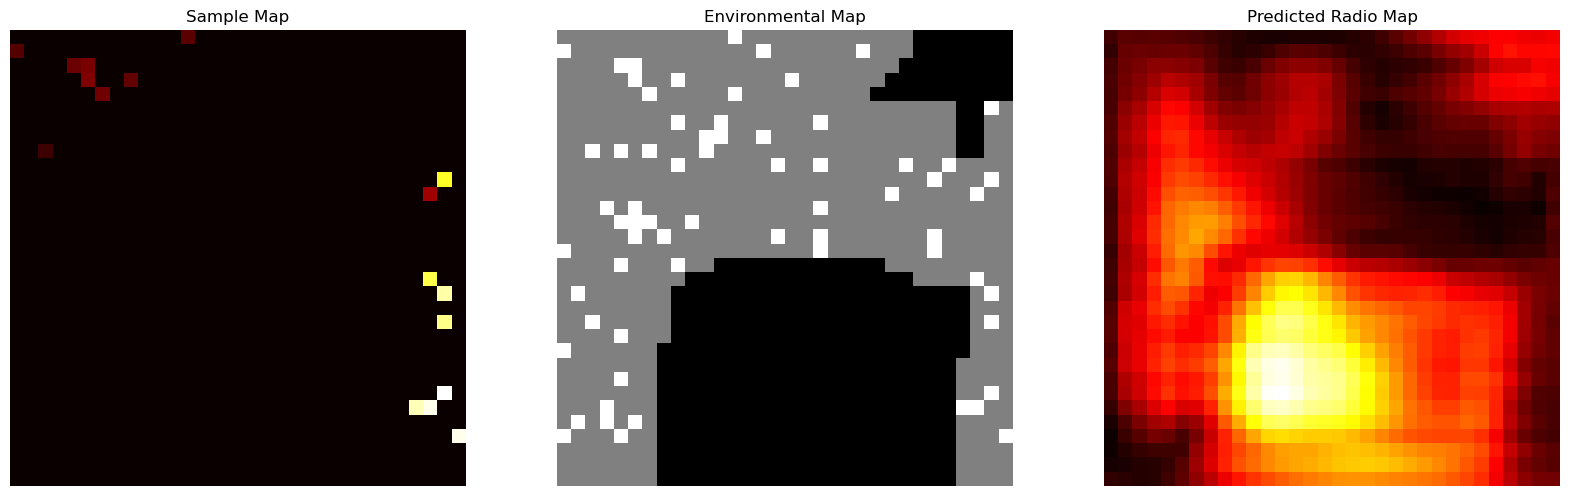

In [46]:
def plot_sample_maps(sample_rate=10,sample=0):
    
    loaded_dict = pickle.load(open("test_data_maps.pkl", "rb")) 


    sample_map,env_mask,y_map,y_mask,channel_pow,pred_map=loaded_dict[sample_rate]

    f=plt.figure(figsize=(20,20))
    f.add_subplot(1,3,1)
    plt.title("Sample Map")
    plt.axis('off')
    plt.imshow(sample_map[sample],cmap="hot")
    plt.savefig("sample_map_"+str(sample_rate)+"_"+str(sample)+".png")


    f.add_subplot(1,3,2)
    plt.title("Environmental Map")
    plt.axis('off')
    plt.imshow((env_mask[sample]),cmap="gray")
    plt.savefig("Env_mask_"+str(sample_rate)+"_"+str(sample)+".png")

    f.add_subplot(1,3,3)
    plt.title("Predicted Radio Map")
    plt.axis('off')
    plt.imshow(pred_map[sample],cmap="hot")
    plt.savefig("pred_map_"+str(sample_rate)+"_"+str(sample)+".png")

plot_sample_maps(sample_rate=10,sample=5)

In [22]:
import pickle
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_sample_maps(sample_rate=10, sample=0):
    
    loaded_dict = pickle.load(open("test_data_maps.pkl", "rb")) 

    sample_map, env_mask, y_map, y_mask, channel_pow, pred_map = loaded_dict[sample_rate]

    # Create a figure and a grid of subplots
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(2, 2, figure=fig)

    # Plot each map on its own subplot using gridspec
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(sample_map[sample], cmap="hot")
    ax1.set_title("Sample Map")
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow((channel_pow[sample]-env_mask[sample]), cmap="gray")
    ax2.set_title("Environmental Map")
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.imshow(y_map[sample], cmap="hot")
    ax3.set_title("Actual Radio Map")
    ax3.axis('off')

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.imshow(pred_map[sample], cmap="hot")
    ax4.set_title("Predicted Radio Map")
    ax4.axis('off')

    # Adjust layout and spacing
    plt.tight_layout()

    # Save the entire figure with individual maps
    plt.savefig(f"sample_maps_grid_{sample_rate}_{sample}.png")

    # Save each map individually
    for i, ax in enumerate([ax1, ax2, ax3, ax4]):
        map_type = ["sample_map", "env_mask", "pred_map", "pred_map"][i]
        ax.figure.savefig(f"{map_type}_{sample_rate}_{sample}.png")

    # Close the figure
    plt.close(fig)

plot_sample_maps(sample_rate=5, sample=5)